Testing windows

#0 Imports

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, export_text

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

from imblearn.combine import SMOTETomek

from sklearn.model_selection import cross_val_score

#1 Load Data

In [2]:
studentInfo = pd.read_csv("studentInfo.csv")

studentVle = pd.read_csv(
    "studentVle.csv",
    engine="python",
    on_bad_lines="skip"
)

studentAssessment = pd.read_csv("studentAssessment.csv")
assessments = pd.read_csv("assessments.csv")
vle = pd.read_csv("vle.csv")
studentRegistration = pd.read_csv(
    "studentRegistration.csv"
)

studentRegistration["date_registration"] = pd.to_numeric(
    studentRegistration["date_registration"],
    errors="coerce"
)

registration_lead = (
    -studentRegistration["date_registration"]
)

In [3]:
# ===== EARLY PREDICTION SETUP =====

cutoffs = [14, 30, 60, 90, 140]
CUTOFF = 30  # temporary single test

# make dates numeric
studentVle["date"] = pd.to_numeric(
    studentVle["date"],
    errors="coerce"
)

assessments["date"] = pd.to_numeric(
    assessments["date"],
    errors="coerce"
)

studentAssessment["date_submitted"] = pd.to_numeric(
    studentAssessment["date_submitted"],
    errors="coerce"
)

# LMS activity available up to cutoff day only
studentVleEarly = (
    studentVle[
        studentVle["date"] <= CUTOFF
    ]
    .copy()
)

# Assessment submissions available up to cutoff day only
studentAssessmentWithDate = studentAssessment.merge(
    assessments[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "date"
        ]
    ],
    on="id_assessment",
    how="left"
)

studentAssessmentEarly = (
    studentAssessmentWithDate[
        studentAssessmentWithDate["date"] <= CUTOFF
    ]
    .copy()
)

print("Cutoff day:", CUTOFF)
print("studentVleEarly:", studentVleEarly.shape)
print("studentAssessmentEarly:", studentAssessmentEarly.shape)

Cutoff day: 60
studentVleEarly: (4499256, 6)
studentAssessmentEarly: (47259, 8)


#2 Data Cleaning

In [4]:
studentAssessment["score"] = pd.to_numeric(
    studentAssessment["score"],
    errors="coerce"
)

In [5]:
print(studentInfo.isnull().sum())
print(studentVle.isnull().sum())
print(studentAssessment.isnull().sum())
print(assessments.isnull().sum())

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64


In [6]:
studentInfo["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


#USING CUTOFFS

In [7]:
# ==========================
# Early prediction datasets
# ==========================

studentVleEarly = (
    studentVle[
        studentVle["date"] <= CUTOFF
    ]
    .copy()
)

studentAssessmentEarly = (
    studentAssessmentWithDate[
        studentAssessmentWithDate["date"] <= CUTOFF
    ]
    .copy()
)

# 3 Feature Engineering

In [8]:
studentVle["date"] = pd.to_numeric(
    studentVle["date"],
    errors="coerce"
)

studentVleEarly = studentVle[
    studentVle["date"] <= CUTOFF
].copy()

print(studentVleEarly["date"].max())

60


In [9]:
assessmentFull = pd.merge(
    studentAssessment,
    assessments,
    on="id_assessment"
)

In [10]:
finalData = pd.merge(
    assessmentFull,
    studentInfo,
    on=["id_student", "code_module", "code_presentation"]
)

In [11]:
finalData["score"] = pd.to_numeric(
    finalData["score"],
    errors="coerce"
)

finalData["weight"] = pd.to_numeric(
    finalData["weight"],
    errors="coerce"
)

finalData = finalData.dropna(
    subset=["score", "weight"]
)

finalData["weighted_score"] = (
    finalData["score"] * finalData["weight"] / 100
)

In [12]:
finalData["date"] = pd.to_numeric(
    finalData["date"],
    errors="coerce"
)
courseworkData = finalData[
    (finalData["assessment_type"] != "Exam") &
    (finalData["date"] <= CUTOFF)
].copy()

In [13]:
courseworkPerformance = courseworkData.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg({
    "weighted_score": "sum",
    "weight": "sum",
}).reset_index()

courseworkPerformance = courseworkPerformance[
    courseworkPerformance["weight"] > 0
]

courseworkPerformance["weighted_average"] = (
    courseworkPerformance["weighted_score"]
    /
    courseworkPerformance["weight"]
)

courseworkPerformance = courseworkPerformance.merge(
    studentInfo[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "final_result"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

In [14]:
dailyActivity = studentVleEarly.groupby(
    ["id_student", "code_module", "code_presentation", "date"]
)["sum_click"].sum().reset_index()

In [15]:
behaviorFeatures = dailyActivity.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg(
    active_days=("date", "count"),
    sum_click=("sum_click", "sum")
).reset_index()

In [16]:
mlData = courseworkPerformance.merge(
    behaviorFeatures,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

In [17]:
mlData["active_days"] = mlData["active_days"].fillna(0)
mlData["sum_click"] = mlData["sum_click"].fillna(0)

mlData["clicks_per_day"] = (
    mlData["sum_click"] /
    (mlData["active_days"] + 1)
)

mlData["clicks_per_day"] = mlData["clicks_per_day"].fillna(0)

mlData["success"] = (
    mlData["final_result"]
    .isin(["Pass", "Distinction"])
    .astype(int)
)

In [18]:
mlData["target_multi"] = (
    mlData["final_result"]
    .replace({
        "Withdrawn": 0,
        "Fail": 1,
        "Pass": 2,
        "Distinction": 3
    })
)

print(
    mlData["target_multi"]
    .value_counts()
)

target_multi
2    11220
1     5163
0     4400
3     2628
Name: count, dtype: int64


/tmp/ipykernel_18920/1852977275.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [19]:
print(mlData.shape)
mlData.head()

(23411, 12)


,id_student,code_module,code_presentation,weighted_score,weight,weighted_average,final_result,active_days,sum_click,clicks_per_day,success,target_multi
0,6516,AAA,2014J,15.600,30.0,0.520000,Pass,48.0,1046.0,21.346939,1,2
1,8462,DDD,2013J,19.675,22.5,0.874444,Withdrawn,37.0,523.0,13.763158,0,0
2,8462,DDD,2014J,12.950,15.0,0.863333,Withdrawn,1.0,10.0,5.000000,0,0
3,11391,AAA,2013J,24.800,30.0,0.826667,Pass,18.0,529.0,27.842105,1,2
4,23629,BBB,2013B,15.690,24.0,0.653750,Fail,12.0,119.0,9.153846,0,1


# 3.1 Additional Feature Engineering

In [20]:
assessmentFull["date"] = pd.to_numeric(
    assessmentFull["date"],
    errors="coerce"
)

assessmentCount = (
    assessmentFull[
        (assessmentFull["assessment_type"] != "Exam") &
        (assessmentFull["date"] <= CUTOFF)
    ]
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])
    .size()
    .reset_index(name="assessment_count")
)

print(assessmentCount.shape)
assessmentCount.head()

(23642, 4)


,id_student,code_module,code_presentation,assessment_count
0,6516,AAA,2014J,2
1,8462,DDD,2013J,2
2,8462,DDD,2014J,2
3,11391,AAA,2013J,2
4,23629,BBB,2013B,3


In [21]:
mlData = mlData.merge(
    assessmentCount,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["assessment_count"] = (
    mlData["assessment_count"]
    .fillna(0)
)

print(mlData.shape)

mlData["assessment_count"].describe()

(23411, 13)


,assessment_count
count,23411.000000
mean,2.008628
std,0.717460
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,4.000000


In [22]:
courseworkCount = (
    assessmentFull[
        (
            assessmentFull["assessment_type"]
            .isin(["TMA","CMA"])
        )
        &
        (
            assessmentFull["date"] <= CUTOFF
        )
    ]
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])
    .size()
    .reset_index(name="coursework_count")
)

In [23]:
mlData = mlData.merge(
    courseworkCount,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["coursework_count"] = (
    mlData["coursework_count"]
    .fillna(0)
)

print(mlData.shape)
mlData["coursework_count"].describe()

(23411, 14)


,coursework_count
count,23411.000000
mean,2.008628
std,0.717460
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,4.000000


In [24]:
mlData[
[
"assessment_count",
"coursework_count"
]
].head(10)

,assessment_count,coursework_count
0,2,2
1,2,2
2,2,2
3,2,2
4,3,3
5,2,2
6,3,3
7,2,2
8,2,2
9,3,3


#3.2 Score Consistency

In [25]:
scoreStd = (
    courseworkData
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])["score"]
    .std()
    .reset_index(name="score_std")
)

scoreStd["score_std"] = (
    scoreStd["score_std"]
    .fillna(0)
)

print(scoreStd.shape)
scoreStd.head()

(23618, 4)


,id_student,code_module,code_presentation,score_std
0,6516,AAA,2014J,8.485281
1,8462,DDD,2013J,7.071068
2,8462,DDD,2014J,7.071068
3,11391,AAA,2013J,4.949747
4,23629,BBB,2013B,20.305993


In [26]:
mlData = mlData.merge(
    scoreStd,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["score_std"] = (
    mlData["score_std"]
    .fillna(0)
)

mlData["score_std"].describe()

,score_std
count,23411.000000
mean,9.265016
std,10.882184
min,0.000000
25%,0.000000
50%,5.656854
75%,14.142136
max,70.003571


In [27]:
print(
    mlData.groupby("final_result")["score_std"]
    .describe()[["mean","50%","75%"]]
)

                   mean       50%        75%
final_result                                
Distinction    7.082937  4.242641   9.712535
Fail           9.917761  7.071068  15.556349
Pass          10.033677  7.071068  14.142136
Withdrawn      7.842293  3.535534  12.727922


#3.3 Engagement Consistency

In [28]:
mlData["clicks_per_assessment"] = (
    mlData["sum_click"] /
    (mlData["assessment_count"]+1)
)

mlData["clicks_per_assessment"] = (
    mlData["clicks_per_assessment"]
    .fillna(0)
)

mlData["clicks_per_assessment"].describe()

,clicks_per_assessment
count,23411.000000
mean,228.125452
std,246.830710
min,0.000000
25%,72.100000
50%,149.250000
75%,299.500000
max,3700.666667


#3.4 Assessment Completion Ration

In [29]:
assessments["date"] = pd.to_numeric(
    assessments["date"],
    errors="coerce"
)

totalAssessments = (
    assessments[
        (assessments["assessment_type"] != "Exam") &
        (assessments["date"] <= CUTOFF)
    ]
    .groupby([
        "code_module",
        "code_presentation"
    ])["id_assessment"]
    .nunique()
    .reset_index(name="total_assessments")
)

print(totalAssessments.head())

  code_module code_presentation  total_assessments
0         AAA             2013J                  2
1         AAA             2014J                  2
2         BBB             2013B                  3
3         BBB             2013J                  3
4         BBB             2014B                  3


In [30]:
totalAssessments.max()

,0
code_module,FFF
code_presentation,2014J
total_assessments,4


In [31]:
mlData = mlData.merge(
    totalAssessments,
    on=[
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["completion_ratio"] = (
    mlData["assessment_count"] /
    mlData["total_assessments"]
)

print(mlData.shape)
mlData["completion_ratio"].describe()

(23411, 18)


,completion_ratio
count,23411.000000
mean,0.928766
std,0.177915
min,0.250000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


#3.5 Click Consistency

In [32]:
dailyClicks = (
    studentVleEarly
    .groupby([
        "id_student",
        "code_module",
        "code_presentation",
        "date"
    ])["sum_click"]
    .sum()
    .reset_index()
)

clickStd = (
    dailyClicks
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])["sum_click"]
    .std()
    .reset_index(name="click_std")
)

clickStd["click_std"] = (
    clickStd["click_std"]
    .fillna(0)
)

clickStd["click_consistency"] = (
    1 /
    (1 + clickStd["click_std"])
)

mlData = mlData.merge(
    clickStd[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "click_consistency"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["click_consistency"] = (
    mlData["click_consistency"]
    .fillna(1)
)

mlData["click_consistency"].describe()

,click_consistency
count,23411.000000
mean,0.068138
std,0.096989
min,0.000731
25%,0.033706
50%,0.048998
75%,0.074574
max,1.000000


#3.6 Study Spread

In [33]:
# Study spread = fraction of available days student was active

mlData["study_spread"] = (
    mlData["active_days"] / CUTOFF
)

mlData["study_spread"] = (
    mlData["study_spread"]
    .fillna(0)
    .clip(0, 1)
)

mlData["study_spread"].describe()

,study_spread
count,23411.000000
mean,0.465464
std,0.267368
min,0.000000
25%,0.250000
50%,0.416667
75%,0.650000
max,1.000000


#3.8 Score Trend

In [34]:
def score_slope(group):

    group = group.sort_values("date")



    if len(group) < 2:

        return 0



    x = np.arange(len(group))

    y = group["score"].values



    slope = np.polyfit(x, y, 1)[0]



    return slope

scoreTrend = (

    courseworkData

    .groupby([

        "id_student",

        "code_module",

        "code_presentation"

    ])

    .apply(score_slope)

    .reset_index(name="score_slope")

)

mlData = mlData.merge(

    scoreTrend,

    on=[

        "id_student",

        "code_module",

        "code_presentation"

    ],

    how="left"

)

mlData["score_slope"] = mlData["score_slope"].fillna(0)

/tmp/ipykernel_18920/2214927025.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(score_slope)


#3.9 Burstiness

In [35]:
daily_clicks = (
    studentVleEarly
    .groupby([
        "id_student",
        "code_module",
        "code_presentation",
        "date"
    ])["sum_click"]
    .sum()
    .reset_index()
)

burst = (
    daily_clicks
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])["sum_click"]
    .agg(["mean", "std"])
    .reset_index()
)

burst["burstiness"] = (
    burst["std"] /
    (burst["mean"] + 1)
)

mlData = mlData.merge(
    burst[[
        "id_student",
        "code_module",
        "code_presentation",
        "burstiness"
    ]],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["burstiness"] = (
    mlData["burstiness"]
    .fillna(0)
)

#3.2.1 VleMerge

In [36]:
vleMerged = studentVleEarly.merge(
    vle[
        [
            "id_site",
            "code_module",
            "code_presentation",
            "activity_type"
        ]
    ],
    on=[
        "id_site",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

print(vleMerged.shape)
vleMerged.head()

(4499256, 7)


,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type
0,AAA,2013J,28400,546652,-10,4,forumng
1,AAA,2013J,28400,546652,-10,1,forumng
2,AAA,2013J,28400,546652,-10,1,forumng
3,AAA,2013J,28400,546614,-10,11,homepage
4,AAA,2013J,28400,546714,-10,1,oucontent


In [37]:
print(vleMerged["date"].max())

60


In [38]:
vleMerged = studentVleEarly.merge(
    vle[
        [
            "id_site",
            "code_module",
            "code_presentation",
            "activity_type"
        ]
    ],
    on=[
        "id_site",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

print(vleMerged.shape)
print(vleMerged["date"].max())
vleMerged.head()

(4499256, 7)
60


,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type
0,AAA,2013J,28400,546652,-10,4,forumng
1,AAA,2013J,28400,546652,-10,1,forumng
2,AAA,2013J,28400,546652,-10,1,forumng
3,AAA,2013J,28400,546614,-10,11,homepage
4,AAA,2013J,28400,546714,-10,1,oucontent


In [39]:
activityClicks = (
    vleMerged
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation",
            "activity_type"
        ]
    )["sum_click"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

print(activityClicks.shape)
activityClicks.head()

(29109, 22)


activity_type,id_student,code_module,code_presentation,dataplus,dualpane,externalquiz,forumng,glossary,homepage,htmlactivity,...,ouelluminate,ouwiki,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url
0,6516,AAA,2014J,7,0,0,234,0,177,0,...,0,0,0,0,0,0,15,0,46,41
1,8462,DDD,2013J,0,0,5,35,0,147,0,...,0,18,0,0,0,0,40,0,191,22
2,8462,DDD,2014J,0,0,0,2,0,7,0,...,0,0,0,0,0,0,0,0,0,0
3,11391,AAA,2013J,0,0,0,98,0,67,0,...,0,0,0,0,0,0,9,0,23,1
4,23629,BBB,2013B,0,0,0,68,0,26,0,...,0,0,0,0,18,0,2,0,5,0


In [40]:
activity_cols = activityClicks.columns[3:]

activityClicks["total_activity_clicks"] = (
    activityClicks[activity_cols]
    .sum(axis=1)
)

selected = [
    "resource",
    "oucontent",
    "homepage",
    "forumng",
    "quiz"
]

for col in selected:
    activityClicks[f"{col}_ratio"] = (
        activityClicks[col]
        /
        (activityClicks["total_activity_clicks"] + 1)
    )

In [41]:
print(
    activityClicks[
        [
            "resource_ratio",
            "oucontent_ratio",
            "homepage_ratio",
            "forumng_ratio",
            "quiz_ratio"
        ]
    ].describe()
)

activity_type  resource_ratio  oucontent_ratio  homepage_ratio  forumng_ratio  \
count            29109.000000     29109.000000    29109.000000   29109.000000   
mean                 0.057175         0.209807        0.239418       0.201226   
std                  0.073701         0.182087        0.114828       0.184346   
min                  0.000000         0.000000        0.000000       0.000000   
25%                  0.013139         0.038239        0.162413       0.048128   
50%                  0.035088         0.181507        0.217765       0.161616   
75%                  0.072289         0.341880        0.289017       0.299333   
max                  0.975000         0.948718        0.963813       0.936353   

activity_type    quiz_ratio  
count          29109.000000  
mean               0.122576  
std                0.176235  
min                0.000000  
25%                0.000000  
50%                0.040351  
75%                0.178937  
max                0.953445  


In [42]:
activityFeatures = activityClicks[
[
"id_student",
"code_module",
"code_presentation",
"resource_ratio",
"oucontent_ratio",
"homepage_ratio",
"forumng_ratio",
"quiz_ratio"
]
]

mlData = mlData.merge(
    activityFeatures,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData.fillna(0, inplace=True)

In [43]:
print(
mlData[
[
"resource_ratio",
"oucontent_ratio",
"homepage_ratio",
"forumng_ratio",
"quiz_ratio"
]
].head()
)

   resource_ratio  oucontent_ratio  homepage_ratio  forumng_ratio  quiz_ratio
0        0.014327         0.502388        0.169054       0.223496        0.00
1        0.076336         0.101145        0.280534       0.066794        0.00
2        0.000000         0.000000        0.636364       0.181818        0.00
3        0.016981         0.624528        0.126415       0.184906        0.00
4        0.016667         0.000000        0.216667       0.566667        0.15


#3.2.2 Demographics

In [44]:
demo = studentInfo[[
    "id_student",
    "code_module",
    "code_presentation",
    "gender",
    "highest_education",
    "age_band",
    "disability",
    "imd_band",
    "num_of_prev_attempts",
    "studied_credits"
]].copy()

print(demo.shape)
demo.head()

(32593, 10)


,id_student,code_module,code_presentation,gender,highest_education,age_band,disability,imd_band,num_of_prev_attempts,studied_credits
0,11391,AAA,2013J,M,HE Qualification,55<=,N,90-100%,0,240
1,28400,AAA,2013J,F,HE Qualification,35-55,N,20-30%,0,60
2,30268,AAA,2013J,F,A Level or Equivalent,35-55,Y,30-40%,0,60
3,31604,AAA,2013J,F,A Level or Equivalent,35-55,N,50-60%,0,60
4,32885,AAA,2013J,F,Lower Than A Level,0-35,N,50-60%,0,60


In [45]:
for col in [
    "gender",
    "highest_education",
    "age_band",
    "disability",
    "imd_band"
]:
    print("\n", col)
    print(
        demo[col].value_counts(
            normalize=True
        ).round(2)
    )


 gender
gender
M    0.55
F    0.45
Name: proportion, dtype: float64

 highest_education
highest_education
A Level or Equivalent          0.43
Lower Than A Level             0.40
HE Qualification               0.15
No Formal quals                0.01
Post Graduate Qualification    0.01
Name: proportion, dtype: float64

 age_band
age_band
0-35     0.70
35-55    0.29
55<=     0.01
Name: proportion, dtype: float64

 disability
disability
N    0.9
Y    0.1
Name: proportion, dtype: float64

 imd_band
imd_band
20-30%     0.11
30-40%     0.11
10-20      0.11
0-10%      0.10
40-50%     0.10
50-60%     0.10
60-70%     0.09
70-80%     0.09
80-90%     0.08
90-100%    0.08
?          0.03
Name: proportion, dtype: float64


In [46]:
demoOutcome = studentInfo[[
    "final_result",
    "gender",
    "highest_education",
    "age_band",
    "disability",
    "imd_band"
]]

for col in [
    "gender",
    "highest_education",
    "age_band",
    "disability"
]:
    print("\n====", col)

    print(
        pd.crosstab(
            demoOutcome[col],
            demoOutcome["final_result"],
            normalize="index"
        ).round(2)
    )


==== gender
final_result  Distinction  Fail  Pass  Withdrawn
gender                                          
F                    0.09  0.21  0.39       0.30
M                    0.09  0.22  0.37       0.32

==== highest_education
final_result                 Distinction  Fail  Pass  Withdrawn
highest_education                                              
A Level or Equivalent               0.11  0.19  0.41       0.29
HE Qualification                    0.15  0.17  0.41       0.27
Lower Than A Level                  0.06  0.26  0.33       0.35
No Formal quals                     0.05  0.27  0.25       0.43
Post Graduate Qualification         0.28  0.11  0.37       0.24

==== age_band
final_result  Distinction  Fail  Pass  Withdrawn
age_band                                        
0-35                 0.08  0.23  0.37       0.32
35-55                0.12  0.19  0.40       0.29
55<=                 0.19  0.13  0.43       0.25

==== disability
final_result  Distinction  Fail  Pass  Wit

In [47]:
mlData = mlData.merge(
    demo,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

print(mlData.shape)

(23411, 34)


In [48]:
categorical = [
    "gender",
    "highest_education",
    "age_band",
    "disability",
    "imd_band"
]

mlData = pd.get_dummies(
    mlData,
    columns=categorical,
    drop_first=True
)

print(mlData.shape)

(23411, 47)


In [49]:
print(mlData.columns.tolist())

['id_student', 'code_module', 'code_presentation', 'weighted_score', 'weight', 'weighted_average', 'final_result', 'active_days', 'sum_click', 'clicks_per_day', 'success', 'target_multi', 'assessment_count', 'coursework_count', 'score_std', 'clicks_per_assessment', 'total_assessments', 'completion_ratio', 'click_consistency', 'study_spread', 'score_slope', 'burstiness', 'resource_ratio', 'oucontent_ratio', 'homepage_ratio', 'forumng_ratio', 'quiz_ratio', 'num_of_prev_attempts', 'studied_credits', 'gender_M', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'age_band_35-55', 'age_band_55<=', 'disability_Y', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'imd_band_?']


#3.2.3 Withdraw index

In [50]:
# mlData["withdrawal_index"] = (
#     mlData["early_click_ratio"]
#     *
#     (
#         1 - mlData["completion_ratio"]
#     )
# )

# mlData["withdrawal_index"] = (
#     mlData["withdrawal_index"]
#     .fillna(0)
# )
# print(
#     mlData[
#         [
#             "early_click_ratio",
#             "completion_ratio",
#             "withdrawal_index"
#         ]
#     ].head()
# )

#3.2.4 Assessment Lateness

In [51]:
# submissionLag = (
#     courseworkData
#     .merge(
#         assessments[
#             [
#                 "id_assessment",
#                 "date"
#             ]
#         ].rename(columns={"date": "due_date"}),
#         on="id_assessment",
#         how="left"
#     )
# )

# submissionLag["days_before_deadline"] = (
#     submissionLag["due_date"]
#     -
#     submissionLag["date_submitted"],
# )

# submissionLag = (
#     submissionLag
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])["days_before_deadline"]
#     .mean()
#     .reset_index(name="avg_submission_lag")
# )

# mlData = mlData.merge(
#     submissionLag,
#     on=[
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# mlData["avg_submission_lag"] = (
#     mlData["avg_submission_lag"]
#     .fillna(0)
# )

#3.2.5 Disappearence ratio

#MIGHT WANT TO REMOVE LATER

In [52]:
gapData = (
    studentVleEarly
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])["date"]
    .agg(
        first_day="min",
        last_day="max"
    )
    .reset_index()
)

gapData = gapData.merge(
    mlData[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "active_days"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

gapData["disappearance_ratio"] = (
    1 -
    gapData["active_days"] /
    (
        gapData["last_day"]
        - gapData["first_day"]
        + 1
    )
)

mlData = mlData.merge(
    gapData[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "disappearance_ratio"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["disappearance_ratio"] = (
    mlData["disappearance_ratio"]
    .fillna(1)
)

In [53]:
print(
    mlData
    .groupby("final_result")[
        [
            "disappearance_ratio"
        ]
    ]
    .median()
)

              disappearance_ratio
final_result                     
Distinction              0.484123
Fail                     0.696429
Pass                     0.580645
Withdrawn                0.658537


#3.2.6 Date registered for the course

In [54]:
registrationData = (
    studentRegistration[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "date_registration"
        ]
    ]
    .copy()
)

registrationData["registration_lead"] = (
    -registrationData["date_registration"]
)

mlData = mlData.merge(
    registrationData[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "registration_lead"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["registration_lead"] = (
    mlData["registration_lead"]
    .fillna(
        mlData["registration_lead"].median()
    )
)

In [55]:
print(
    mlData
    .groupby("final_result")[
        "registration_lead"
    ]
    .median()
)

final_result
Distinction    52.0
Fail           51.0
Pass           55.0
Withdrawn      58.0
Name: registration_lead, dtype: float64


In [56]:
print(
    mlData
    .groupby("final_result")[
        "registration_lead"
    ]
    .describe()
)

                count       mean        std    min   25%   50%     75%    max
final_result                                                                 
Distinction    2628.0  66.932648  47.751981  -32.0  29.0  52.0   95.00  303.0
Fail           5163.0  64.153980  45.886077 -124.0  28.0  51.0   93.00  289.0
Pass          11220.0  68.331640  47.843992 -101.0  29.0  55.0   99.00  310.0
Withdrawn      4400.0  71.550909  50.764988 -167.0  29.0  58.0  102.25  311.0


#3.2.7 late activity ratio

In [57]:
# # clicks in last 25% of activity window / total clicks

# course_end = 240

# lateClicks = (
#     studentVle[
#         studentVle["date"] >= (
#             course_end * 0.75
#         )
#     ]
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])["sum_click"]
#     .sum()
#     .reset_index(
#         name="late_clicks"
#     )
# )

# totalClicks = (
#     studentVle
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])["sum_click"]
#     .sum()
#     .reset_index(
#         name="total_clicks"
#     )
# )

# lateActivity = (
#     totalClicks
#     .merge(
#         lateClicks,
#         on=[
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ],
#         how="left"
#     )
# )

# lateActivity["late_clicks"] = (
#     lateActivity["late_clicks"]
#     .fillna(0)
# )

# lateActivity["late_activity_ratio"] = (
#     lateActivity["late_clicks"]
#     /
#     (
#         lateActivity["total_clicks"]
#         + 1
#     )
# )

# mlData = mlData.merge(
#     lateActivity[
#         [
#             "id_student",
#             "code_module",
#             "code_presentation",
#             "late_activity_ratio"
#         ]
#     ],
#     on=[
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# mlData["late_activity_ratio"] = (
#     mlData["late_activity_ratio"]
#     .fillna(0)
# )

#3.2.8 Late completion ratio

In [58]:
# # ===== Completion split: early / mid / late =====

# course_end = 240

# early = course_end * 0.33
# mid = course_end * 0.66

# completed = courseworkData.copy()

# # Early completed submissions
# earlyComp = (
#     completed[
#         completed["date_submitted"] < early
#     ]
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])
#     .size()
#     .reset_index(name="early_done")
# )

# # Mid completed submissions
# midComp = (
#     completed[
#         (completed["date_submitted"] >= early)
#         &
#         (completed["date_submitted"] < mid)
#     ]
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])
#     .size()
#     .reset_index(name="mid_done")
# )

# # Late completed submissions
# lateComp = (
#     completed[
#         completed["date_submitted"] >= mid
#     ]
#     .groupby([
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ])
#     .size()
#     .reset_index(name="late_done")
# )

# # Combine early, mid, late counts
# completionSplit = (
#     earlyComp
#     .merge(
#         midComp,
#         on=[
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ],
#         how="outer"
#     )
#     .merge(
#         lateComp,
#         on=[
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ],
#         how="outer"
#     )
# )

# completionSplit = completionSplit.fillna(0)

# # Add total possible assessments
# completionSplit = completionSplit.merge(
#     totalAssessments,
#     on=[
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# # Create period completion ratios
# completionSplit["early_completion_ratio"] = (
#     completionSplit["early_done"]
#     /
#     completionSplit["total_assessments"]
# )

# completionSplit["mid_completion_ratio"] = (
#     completionSplit["mid_done"]
#     /
#     completionSplit["total_assessments"]
# )

# completionSplit["late_completion_ratio"] = (
#     completionSplit["late_done"]
#     /
#     completionSplit["total_assessments"]
# )

# # Merge into mlData
# mlData = mlData.merge(
#     completionSplit[
#         [
#             "id_student",
#             "code_module",
#             "code_presentation",
#             "early_completion_ratio",
#             "mid_completion_ratio",
#             "late_completion_ratio"
#         ]
#     ],
#     on=[
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# # Fill missing values
# for col in [
#     "early_completion_ratio",
#     "mid_completion_ratio",
#     "late_completion_ratio"
# ]:
#     mlData[col] = mlData[col].fillna(0)

# # Check
# print(
#     mlData[
#         [
#             "early_completion_ratio",
#             "mid_completion_ratio",
#             "late_completion_ratio"
#         ]
#     ]
#     .describe()
# )

#3.2.9 Persistance score

In [59]:
# mlData["persistence_score"] = (
#     0.5 * mlData["completion_ratio"]
#     +
#     0.3 * mlData["late_activity_ratio"]
#     +
#     0.2 * (
#         mlData["active_days"]
#         /
#         mlData["active_days"].max()
#     )
# )

In [60]:
# (
#     mlData
#     .groupby("final_result")[
#         "persistence_score"
#     ]
#     .describe()
#     .round(3)
# )

In [61]:
# print(
#     mlData[
#         [
#             "persistence_score",
#             "completion_ratio",
#             "late_activity_ratio",
#             "active_days"
#         ]
#     ]
#     .corr()
#     .round(3)
# )

#3.2.10

In [62]:
# ===== Deadline Panic Score - early-prediction safe =====

import gc
import pandas as pd

assessDays = (
    courseworkData[
        [
            "code_module",
            "code_presentation",
            "date"
        ]
    ]
    .drop_duplicates()
    .rename(columns={"date": "assessment_day"})
)

panic_parts = []

for _, row in assessDays.iterrows():

    module = row["code_module"]
    presentation = row["code_presentation"]
    day = row["assessment_day"]

    temp = studentVleEarly[
        (studentVleEarly["code_module"] == module) &
        (studentVleEarly["code_presentation"] == presentation) &
        (studentVleEarly["date"] >= day - 14) &
        (studentVleEarly["date"] <= day)
    ].copy()

    if temp.empty:
        continue

    temp["is_last3"] = temp["date"] >= day - 3

    agg = (
        temp
        .groupby([
            "id_student",
            "code_module",
            "code_presentation"
        ])
        .agg(
            last14_clicks=("sum_click", "sum"),
            last3_clicks=("sum_click", lambda x: x[temp.loc[x.index, "is_last3"]].sum())
        )
        .reset_index()
    )

    panic_parts.append(agg)

    del temp, agg
    gc.collect()

if len(panic_parts) > 0:
    panic = pd.concat(panic_parts, ignore_index=True)

    panic = (
        panic
        .groupby([
            "id_student",
            "code_module",
            "code_presentation"
        ])
        .agg(
            last14_clicks=("last14_clicks", "sum"),
            last3_clicks=("last3_clicks", "sum")
        )
        .reset_index()
    )

    panic["deadline_panic_score"] = (
        panic["last3_clicks"] /
        (panic["last14_clicks"] + 1)
    )

    mlData = mlData.drop(
        columns=["deadline_panic_score"],
        errors="ignore"
    )

    mlData = mlData.merge(
        panic[
            [
                "id_student",
                "code_module",
                "code_presentation",
                "deadline_panic_score"
            ]
        ],
        on=[
            "id_student",
            "code_module",
            "code_presentation"
        ],
        how="left"
    )

else:
    mlData["deadline_panic_score"] = 0

mlData["deadline_panic_score"] = (
    mlData["deadline_panic_score"]
    .fillna(0)
)

mlData["deadline_panic_score"].describe()

,deadline_panic_score
count,23411.000000
mean,0.381881
std,0.234939
min,0.000000
25%,0.214100
50%,0.348936
75%,0.522124
max,0.998198


#Assessment focus

In [63]:
# ===== Assessment Focus - early-prediction safe =====

import gc
import pandas as pd

assessDays = (
    courseworkData[
        [
            "code_module",
            "code_presentation",
            "date"
        ]
    ]
    .drop_duplicates()
    .rename(columns={"date": "assessment_day"})
)

focus_parts = []

for _, row in assessDays.iterrows():

    module = row["code_module"]
    presentation = row["code_presentation"]
    day = row["assessment_day"]

    temp = studentVleEarly[
        (studentVleEarly["code_module"] == module) &
        (studentVleEarly["code_presentation"] == presentation) &
        (studentVleEarly["date"] >= day - 7) &
        (studentVleEarly["date"] <= day)
    ]

    if temp.empty:
        continue

    agg = (
        temp
        .groupby([
            "id_student",
            "code_module",
            "code_presentation"
        ])["sum_click"]
        .sum()
        .reset_index(name="assessment_clicks")
    )

    focus_parts.append(agg)

    del temp, agg
    gc.collect()

totalClicks = (
    studentVleEarly
    .groupby([
        "id_student",
        "code_module",
        "code_presentation"
    ])["sum_click"]
    .sum()
    .reset_index(name="total_clicks")
)

if len(focus_parts) > 0:

    focusClicks = pd.concat(
        focus_parts,
        ignore_index=True
    )

    focusClicks = (
        focusClicks
        .groupby([
            "id_student",
            "code_module",
            "code_presentation"
        ])["assessment_clicks"]
        .sum()
        .reset_index()
    )

    focus = totalClicks.merge(
        focusClicks,
        on=[
            "id_student",
            "code_module",
            "code_presentation"
        ],
        how="left"
    )

else:

    focus = totalClicks.copy()
    focus["assessment_clicks"] = 0

focus["assessment_clicks"] = (
    focus["assessment_clicks"]
    .fillna(0)
)

focus["assessment_focus"] = (
    focus["assessment_clicks"]
    /
    (
        focus["total_clicks"] + 1
    )
)

mlData = mlData.drop(
    columns=["assessment_focus"],
    errors="ignore"
)

mlData = mlData.merge(
    focus[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "assessment_focus"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["assessment_focus"] = (
    mlData["assessment_focus"]
    .fillna(0)
)

print(mlData["assessment_focus"].describe())

count    23411.000000
mean         0.351760
std          0.229957
min          0.000000
25%          0.187219
50%          0.303514
75%          0.473417
max          1.750000
Name: assessment_focus, dtype: float64


#Resource shift score

In [64]:
# studentVleTyped = (
#     studentVle.merge(
#         vle[
#             [
#                 "id_site",
#                 "activity_type"
#             ]
#         ],
#         on="id_site",
#         how="left"
#     )
# )

# print(studentVleTyped.columns)

In [65]:
# # ===== Resource Shift Score =====

# import gc

# resource_window = (
#     studentVleTyped[
#         studentVle["date"] >= (
#             course_end - 14
#         )
#     ]
# )

# total_window = (
#     resource_window
#     .groupby(
#         [
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ]
#     )["sum_click"]
#     .sum()
#     .reset_index(
#         name="window_clicks"
#     )
# )

# resource_types = [
#     "resource",
#     "oucontent",
#     "forumng",
#     "quiz"
# ]

# for res in resource_types:

#     temp = (
#         resource_window[
#             resource_window["activity_type"]
#             ==
#             res
#         ]
#         .groupby(
#             [
#                 "id_student",
#                 "code_module",
#                 "code_presentation"
#             ]
#         )["sum_click"]
#         .sum()
#         .reset_index(
#             name=f"{res}_late"
#         )
#     )

#     temp = total_window.merge(
#         temp,
#         on=[
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ],
#         how="left"
#     )

#     temp[f"{res}_late"] = (
#         temp[f"{res}_late"]
#         .fillna(0)
#     )

#     temp[f"{res}_late_ratio"] = (
#         temp[f"{res}_late"]
#         /
#         (
#             temp["window_clicks"]
#             + 1
#         )
#     )

#     mlData = mlData.drop(
#         columns=[f"{res}_late_ratio"],
#         errors="ignore"
#     )

#     mlData = mlData.merge(
#         temp[
#             [
#                 "id_student",
#                 "code_module",
#                 "code_presentation",
#                 f"{res}_late_ratio"
#             ]
#         ],
#         on=[
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ],
#         how="left"
#     )

#     mlData[
#         f"{res}_late_ratio"
#     ] = (
#         mlData[
#             f"{res}_late_ratio"
#         ]
#         .fillna(0)
#     )

#     del temp
#     gc.collect()

# del resource_window
# del total_window
# gc.collect()



In [66]:
mlData["ineffective_study_score"] = (
    mlData["assessment_focus"] *
    (1 - mlData["weighted_average"])
)

# mlData["disengaged_performer_score"] = (
#     mlData["weighted_average"] *
#     (1 - mlData["late_activity_ratio"]) *
#     mlData["withdrawal_index"]
# )

# mlData["late_success_score"] = (
#     mlData["late_completion_ratio"] *
#     mlData["weighted_average"]
# )

In [67]:
# # recreate resource_window
# resource_window = (
#     studentVleTyped[
#         studentVleTyped["date"] >= (
#             course_end - 14
#         )
#     ]
# )

# # recreate total_window
# total_window = (
#     resource_window
#     .groupby(
#         [
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ]
#     )["sum_click"]
#     .sum()
#     .reset_index(
#         name="window_clicks"
#     )
# )

# # ===== Homepage Late Ratio =====

# temp = (
#     resource_window[
#         resource_window["activity_type"] == "homepage"
#     ]
#     .groupby(
#         [
#             "id_student",
#             "code_module",
#             "code_presentation"
#         ]
#     )["sum_click"]
#     .sum()
#     .reset_index(
#         name="homepage_late"
#     )
# )

# temp = total_window.merge(
#     temp,
#     on=[
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# temp["homepage_late"] = (
#     temp["homepage_late"]
#     .fillna(0)
# )

# temp["homepage_late_ratio"] = (
#     temp["homepage_late"]
#     /
#     (
#         temp["window_clicks"] + 1
#     )
# )

# mlData = mlData.drop(
#     columns=["homepage_late_ratio"],
#     errors="ignore"
# )

# mlData = mlData.merge(
#     temp[
#         [
#             "id_student",
#             "code_module",
#             "code_presentation",
#             "homepage_late_ratio"
#         ]
#     ],
#     on=[
#         "id_student",
#         "code_module",
#         "code_presentation"
#     ],
#     how="left"
# )

# mlData["homepage_late_ratio"] = (
#     mlData["homepage_late_ratio"]
#     .fillna(0)
# )

In [68]:
mlData = mlData.merge(
    studentInfo[
        [
            "id_student",
            "code_module",
            "code_presentation",
            "region",
            "imd_band"
        ]
    ],
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

In [69]:
region_dummies = pd.get_dummies(
    mlData["region"],
    prefix="region",
    drop_first=True
)

imd_dummies = pd.get_dummies(
    mlData["imd_band"],
    prefix="imd",
    drop_first=True
)

mlData = pd.concat(
    [mlData, region_dummies, imd_dummies],
    axis=1
)

#Recovery after failure

In [70]:
ass = studentAssessmentEarly.copy()

ass["score"] = pd.to_numeric(
    ass["score"],
    errors="coerce"
)

ass = ass.dropna(
    subset=["score"]
)

median_score = ass["score"].median()

ass["bad_assessment"] = (
    ass["score"] < median_score
)
ass["bad_assessment"] = ass["score"] < median_score

clicks = (
    studentVleEarly
    .groupby(["id_student", "date"])["sum_click"]
    .sum()
    .reset_index()
)

rows = []

for sid in ass["id_student"].unique():

    s = ass[ass["id_student"] == sid]
    bad = s[s["bad_assessment"]]

    if len(bad) == 0:
        rows.append([sid, 0])
        continue

    d = bad["date"].iloc[0]

    before = clicks[
        (clicks["id_student"] == sid) &
        (clicks["date"] < d)
    ]["sum_click"].mean()

    after = clicks[
        (clicks["id_student"] == sid) &
        (clicks["date"] >= d)
    ]["sum_click"].mean()

    delta = (
        after - before
        if pd.notna(before) and pd.notna(after)
        else 0
    )

    rows.append([sid, delta])

recovery_click = pd.DataFrame(
    rows,
    columns=["id_student", "post_failure_engagement_delta"]
)

mlData = mlData.drop(
    columns=["post_failure_engagement_delta"],
    errors="ignore"
)

mlData = mlData.merge(
    recovery_click,
    on="id_student",
    how="left"
)

mlData["post_failure_engagement_delta"] = (
    mlData["post_failure_engagement_delta"]
    .fillna(0)
)

In [71]:
(
mlData
.groupby("target_multi")
["post_failure_engagement_delta"]
.mean()
)

,post_failure_engagement_delta
target_multi,
0,-3.708087
1,-3.630808
2,-2.900082
3,-1.244982


#RECOVERY SLOPE

In [72]:
# ===== Recovery Slope (30-day data) =====

ass = studentAssessmentEarly.copy()

# Ensure scores are numeric
ass["score"] = pd.to_numeric(
    ass["score"],
    errors="coerce"
)

# Order assessments chronologically for each student
ass = ass.sort_values(
    [
        "id_student",
        "code_module",
        "code_presentation",
        "date"
    ]
)

# Previous assessment score
ass["prev_score"] = (
    ass
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )["score"]
    .shift(1)
)

# Improvement (or decline) between consecutive assessments
ass["score_change"] = (
    ass["score"] -
    ass["prev_score"]
)

# Average improvement
recoverySlope = (
    ass
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )["score_change"]
    .mean()
    .reset_index(name="recovery_slope")
)

# Replace old feature if rerunning notebook
mlData = mlData.drop(
    columns=["recovery_slope"],
    errors="ignore"
)

# Merge
mlData = mlData.merge(
    recoverySlope,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

mlData["recovery_slope"] = (
    mlData["recovery_slope"]
    .fillna(0)
)

print(
    mlData["recovery_slope"].describe()
)

count    23411.000000
mean         1.901485
std         18.495986
min        -90.000000
25%         -4.000000
50%          0.000000
75%          9.000000
max         99.000000
Name: recovery_slope, dtype: float64


In [73]:
# CLEANUP BEFORE TRAINING

# remove duplicate columns
mlData = mlData.loc[
    :,
    ~mlData.columns.duplicated()
]

# fill trajectory feature NaNs
mlData["recovery_slope"] = (
    mlData["recovery_slope"]
    .fillna(0)
)


In [74]:
# import numpy as np

# denom = mlData["avg_submission_lag"] + 1

# mlData["completion_efficiency"] = np.where(
#     denom.abs() < 1e-6,
#     0,
#     mlData["late_completion_ratio"] / denom
# )

# mlData["completion_efficiency"] = (
#     mlData["completion_efficiency"]
#     .replace([np.inf, -np.inf], 0)
#     .fillna(0)
# )

# Baseline v2 — Leakage-Free Assessment Features

The three assessment-derived active features (`weighted_average`,
`clicks_per_assessment`, `recovery_slope`) were computed in v1 by filtering on the
assessment **due date** (`assessments.date <= CUTOFF`). That leaks scores submitted
*after* the cutoff and discards scores submitted *before* it. The cells below recompute
those three features using **`date_submitted <= CUTOFF`** — the only information truly
available at the cutoff — and overwrite the corresponding `mlData` columns. Everything
else (row membership, split, models, other features) is unchanged. See
`reports/leakage_audit.md`.

In [ ]:
# ============================================================
# Baseline v2 - leakage-free assessment features
# ============================================================
# Leakage fixed (see reports/leakage_audit.md):
#   v1 filtered coursework/assessments by the assessment DUE date
#   (assessments.date <= CUTOFF). That (a) LEAKS scores submitted AFTER the cutoff
#   for work due before it, and (b) DISCARDS scores submitted BEFORE the cutoff for
#   work due after it. v2 filters by date_submitted <= CUTOFF, the day a score first
#   exists - the only information truly available at the cutoff. The ONLY change is
#   the filter predicate; grouping/weighting/fillna/membership/split/models are
#   unchanged, so Baseline v1 vs v2 is a clean feature-by-feature comparison.
# Affected active features: weighted_average, clicks_per_assessment, recovery_slope.

# --- weighted_average (v2): mirror of #17-#18 with date_submitted filter ---
finalData["date_submitted"] = pd.to_numeric(finalData["date_submitted"], errors="coerce")

courseworkData_v2 = finalData[
    (finalData["assessment_type"] != "Exam") &
    (finalData["date_submitted"] <= CUTOFF)
].copy()

courseworkPerformance_v2 = (
    courseworkData_v2
    .groupby(["id_student", "code_module", "code_presentation"])
    .agg({"weighted_score": "sum", "weight": "sum"})
    .reset_index()
)
courseworkPerformance_v2 = courseworkPerformance_v2[courseworkPerformance_v2["weight"] > 0]
courseworkPerformance_v2["weighted_average_v2"] = (
    courseworkPerformance_v2["weighted_score"] / courseworkPerformance_v2["weight"]
)

mlData = mlData.drop(columns=["weighted_average_v2"], errors="ignore")
mlData = mlData.merge(
    courseworkPerformance_v2[
        ["id_student", "code_module", "code_presentation", "weighted_average_v2"]
    ],
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
mlData["weighted_average"] = mlData["weighted_average_v2"].fillna(0)
mlData = mlData.drop(columns=["weighted_average_v2"])

# --- assessment_count (v2) -> clicks_per_assessment (v2): mirror of #26 + #36 ---
assessmentFull["date_submitted"] = pd.to_numeric(
    assessmentFull["date_submitted"], errors="coerce"
)

assessmentCount_v2 = (
    assessmentFull[
        (assessmentFull["assessment_type"] != "Exam") &
        (assessmentFull["date_submitted"] <= CUTOFF)
    ]
    .groupby(["id_student", "code_module", "code_presentation"])
    .size()
    .reset_index(name="assessment_count_v2")
)

mlData = mlData.drop(columns=["assessment_count_v2"], errors="ignore")
mlData = mlData.merge(
    assessmentCount_v2,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
mlData["assessment_count_v2"] = mlData["assessment_count_v2"].fillna(0)
mlData["clicks_per_assessment"] = (
    mlData["sum_click"] / (mlData["assessment_count_v2"] + 1)
).fillna(0)
mlData = mlData.drop(columns=["assessment_count_v2"])

# --- recovery_slope (v2): mirror of #100 with date_submitted filter ---
ass_v2 = studentAssessmentWithDate.copy()
ass_v2["score"] = pd.to_numeric(ass_v2["score"], errors="coerce")
ass_v2["date_submitted"] = pd.to_numeric(ass_v2["date_submitted"], errors="coerce")
ass_v2 = ass_v2[ass_v2["date_submitted"] <= CUTOFF]
ass_v2 = ass_v2.sort_values(
    ["id_student", "code_module", "code_presentation", "date"]
)
ass_v2["prev_score"] = (
    ass_v2.groupby(["id_student", "code_module", "code_presentation"])["score"].shift(1)
)
ass_v2["score_change"] = ass_v2["score"] - ass_v2["prev_score"]
recoverySlope_v2 = (
    ass_v2
    .groupby(["id_student", "code_module", "code_presentation"])["score_change"]
    .mean()
    .reset_index(name="recovery_slope_v2")
)

mlData = mlData.drop(columns=["recovery_slope_v2"], errors="ignore")
mlData = mlData.merge(
    recoverySlope_v2,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
mlData["recovery_slope"] = mlData["recovery_slope_v2"].fillna(0)
mlData = mlData.drop(columns=["recovery_slope_v2"])

print("[v2] leakage-free features applied at CUTOFF =", CUTOFF)
print(mlData[["weighted_average", "clicks_per_assessment", "recovery_slope"]].describe())


# Baseline v3 — Registered Risk Population + Grouped Evaluation

Two methodological fixes over v2 (evidence: `reports/evaluation_validity_audit.md`):

1. **Sample membership (survivorship).** v1/v2 `mlData` only contains students who submitted
weighted coursework due before the cutoff — membership depended on future behaviour and
silently dropped most Withdrawn students (96% of registered pairs at cutoff 14, 41% at 30).
v3 seeds prediction cases from **all registered (student, module, presentation) pairs** still
enrolled at the cutoff; missing information is represented explicitly
(`has_vle_activity`, `has_coursework` + zero-filled features) instead of dropping rows.
Pairs whose outcome is already decided at the cutoff are excluded (unregistered ≤ cutoff,
or registered after it).

2. **Grouped evaluation.** Deployment predicts **unseen students**, but the v1/v2 random row
split lets the same `id_student` (multi-enrollment) appear in both train and test.
v3 uses `GroupShuffleSplit(group=id_student)` so no student crosses the split.

Models and hyperparameters are **identical** to v1/v2; feature values reuse the leakage-free
v2 tables. `mlData` and the v1/v2 sections below are untouched (history preserved).

In [ ]:
# ============================================================
# Baseline v3 - registered risk population + grouped evaluation
# ============================================================
# Two methodological fixes (see reports/evaluation_validity_audit.md):
#
# 1) SAMPLE MEMBERSHIP (survivorship): v1/v2 mlData only contains students who
#    submitted weighted coursework due before the cutoff - membership itself
#    depended on future behaviour and silently dropped most Withdrawn students.
#    v3 seeds prediction cases from ALL registered (student, module, presentation)
#    pairs (studentInfo), keeping every student who is still enrolled at the
#    cutoff. Missing information is represented explicitly (has_vle_activity,
#    has_coursework indicators + zero-filled features) instead of dropping rows.
#    Pairs whose outcome is already decided at prediction time are excluded:
#    unregistered on/before CUTOFF (withdrawal already observed) or registered
#    after CUTOFF (not yet enrolled on prediction day).
#
# 2) EVALUATION (grouped split): the same id_student can appear in several
#    module-presentations; the v1/v2 random row split places the same student in
#    both train and test, inflating metrics vs the deployment scenario
#    (predicting for unseen students). v3 uses GroupShuffleSplit with
#    group=id_student so no student appears on both sides.
#
# Models and hyperparameters are IDENTICAL to v1/v2. Feature values reuse the
# leakage-free v2 tables. mlData / the v1-v2 sections below are untouched.

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

KEY3 = ["id_student", "code_module", "code_presentation"]

reg3 = studentRegistration.copy()
reg3["date_registration"] = pd.to_numeric(reg3["date_registration"], errors="coerce")
reg3["date_unregistration"] = pd.to_numeric(reg3["date_unregistration"], errors="coerce")

pop3 = studentInfo[KEY3 + ["final_result", "highest_education"]].merge(
    reg3[KEY3 + ["date_registration", "date_unregistration"]],
    on=KEY3, how="left",
)

# prediction cases at day CUTOFF = still-enrolled registered pairs
mlDataV3 = pop3[
    ~(pop3["date_unregistration"] <= CUTOFF) &
    ~(pop3["date_registration"] > CUTOFF)
].copy()

# leakage-free feature tables (all computed from <=CUTOFF information above)
mlDataV3 = mlDataV3.merge(behaviorFeatures, on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(activityFeatures, on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(burst[KEY3 + ["burstiness"]], on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(focus[KEY3 + ["assessment_focus"]], on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(
    courseworkPerformance_v2[KEY3 + ["weighted_average_v2"]], on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(assessmentCount_v2, on=KEY3, how="left")
mlDataV3 = mlDataV3.merge(recoverySlope_v2, on=KEY3, how="left")

# explicit availability indicators instead of dropping students
mlDataV3["has_vle_activity"] = mlDataV3["active_days"].notna().astype(int)
mlDataV3["has_coursework"] = mlDataV3["weighted_average_v2"].notna().astype(int)

for _c in ["active_days", "sum_click", "resource_ratio", "oucontent_ratio",
           "homepage_ratio", "forumng_ratio", "quiz_ratio", "burstiness",
           "assessment_focus", "weighted_average_v2", "assessment_count_v2",
           "recovery_slope_v2"]:
    mlDataV3[_c] = mlDataV3[_c].fillna(0)

mlDataV3["weighted_average"] = mlDataV3["weighted_average_v2"]
mlDataV3["recovery_slope"] = mlDataV3["recovery_slope_v2"]
mlDataV3["clicks_per_day"] = mlDataV3["sum_click"] / (mlDataV3["active_days"] + 1)
mlDataV3["clicks_per_assessment"] = (
    mlDataV3["sum_click"] / (mlDataV3["assessment_count_v2"] + 1)
)
mlDataV3["study_spread"] = (mlDataV3["active_days"] / CUTOFF).clip(0, 1)

mlDataV3["target_multi"] = (
    mlDataV3["final_result"]
    .replace({"Withdrawn": 0, "Fail": 1, "Pass": 2, "Distinction": 3})
    .astype(int)
)

mlDataV3 = pd.get_dummies(mlDataV3, columns=["highest_education"], drop_first=True)

v3_features = [
    "weighted_average", "active_days", "clicks_per_day", "clicks_per_assessment",
    "study_spread", "burstiness", "resource_ratio", "oucontent_ratio",
    "homepage_ratio", "forumng_ratio", "quiz_ratio", "assessment_focus",
    "recovery_slope", "has_vle_activity", "has_coursework",
] + [c for c in mlDataV3.columns if c.startswith("highest_education_")]

X_v3 = mlDataV3[v3_features]
y_v3 = mlDataV3["target_multi"]
groups_v3 = mlDataV3["id_student"].values

gss_v3 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr3, te3 = next(gss_v3.split(X_v3, y_v3, groups_v3))
X3_train, X3_test = X_v3.iloc[tr3], X_v3.iloc[te3]
y3_train, y3_test = y_v3.iloc[tr3], y_v3.iloc[te3]

# no student on both sides
assert (
    len(set(mlDataV3.iloc[tr3]["id_student"]) & set(mlDataV3.iloc[te3]["id_student"])) == 0
)

v3_models = {
    "logreg": SkPipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=5000, random_state=42, class_weight="balanced")),
    ]),
    "decision_tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "random_forest": RandomForestClassifier(
        random_state=42, class_weight="balanced", n_estimators=300),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, objective="multi:softmax",
        num_class=4, eval_metric="mlogloss"),
}

baseline_v3_results = {
    "cutoff": CUTOFF,
    "mlDataV3_shape": list(mlDataV3.shape),
    "features": list(X_v3.columns),
    "split": {
        "strategy": "GroupShuffleSplit(group=id_student)",
        "test_size": 0.2, "random_state": 42,
        "train_rows": int(len(tr3)), "test_rows": int(len(te3)),
        "train_students": int(mlDataV3.iloc[tr3]["id_student"].nunique()),
        "test_students": int(mlDataV3.iloc[te3]["id_student"].nunique()),
    },
    "target_dist": {int(k): int(v) for k, v in y_v3.value_counts().sort_index().items()},
    "test_dist": {int(k): int(v) for k, v in y3_test.value_counts().sort_index().items()},
    "models": {},
}

for _name, _m in v3_models.items():
    _m.fit(X3_train, y3_train)
    _p = _m.predict(X3_test)
    baseline_v3_results["models"][_name] = {
        "accuracy": float(accuracy_score(y3_test, _p)),
        "macro_f1": float(f1_score(y3_test, _p, average="macro")),
    }
    print(f"[v3] {_name:15s} acc={baseline_v3_results['models'][_name]['accuracy']:.4f} "
          f"macroF1={baseline_v3_results['models'][_name]['macro_f1']:.4f}")

print("[v3] CUTOFF =", CUTOFF, "| mlDataV3:", mlDataV3.shape,
      "| features:", len(v3_features))
print("[v3] target distribution:", baseline_v3_results["target_dist"])

# Baseline v4 — Promoted Experiment-002 Features (verified)

Baseline v4 = the v3 population, protocol, and models, plus **16 independently verified
features** promoted from Experiment 002 (35 active features total). Promotion evidence in
`reports/baseline_v4_feature_audit.md`:

- every feature **recomputed independently** from raw OULAD tables via a different code path
  and matched value-for-value (≤1e-9) at cutoffs 30 and 90;
- every dependency traced to raw columns with hard `≤ CUTOFF` filters (asserted in-cell);
- redundancy-scanned against the official v3 features (one within-new pair flagged at
  r=0.948; both members survive leave-one-feature-out checks);
- all four groups pass pre-registered leave-one-group-out ablations at cutoffs 30 **and** 90.

Promoted groups: `module_norm` (cohort percentile ranks), `submission_timing`,
`recent_windows`, `recency_decay`. The v1/v2/v3 sections above are untouched; `mlDataV3` is
read, never modified.

In [ ]:
# ============================================================
# Baseline v4 - promoted Experiment-002 features (verified)
# ============================================================
# Promotion basis (reports/baseline_v4_feature_audit.md): every feature below
# was (1) independently recomputed from raw OULAD tables via a different code
# path and matched value-for-value (<=1e-9); (2) traced to raw columns and
# proven leakage-free (hard <=CUTOFF filters, asserted); (3) checked for
# redundancy against the official v3 features; (4) confirmed by leave-one-
# group-out ablations on train-only grouped CV at cutoffs 30 and 90.
#
# PROMOTED GROUPS: module_norm, submission_timing, recent_windows, recency_decay (all 4 groups / 16 features passed)
#
# v4 = v3 population + v3 features + promoted features. The v3 section above
# is untouched; mlDataV3 is only read, never modified. Same 4 models, same
# grouped protocol (GroupShuffleSplit, group=id_student, seed 42).

_C4 = CUTOFF
KEY4 = ["id_student", "code_module", "code_presentation"]

# --- VLE-derived (studentVle.date <= CUTOFF; date is the day a click happened)
_sv4 = studentVle[KEY4 + ["id_site", "date", "sum_click"]].copy()
_sv4["date"] = pd.to_numeric(_sv4["date"], errors="coerce")
_sv4 = _sv4[_sv4["date"] <= _C4]
assert _sv4["date"].max() <= _C4  # temporal guard

_v4parts = []
for _name, _lo, _hi in [("w1_clicks", _C4 - 6, _C4), ("w2_clicks", _C4 - 13, _C4 - 7),
                         ("w3_clicks", _C4 - 20, _C4 - 14), ("w4_clicks", _C4 - 27, _C4 - 21)]:
    _v4parts.append(_sv4[(_sv4["date"] >= _lo) & (_sv4["date"] <= _hi)]
                    .groupby(KEY4)["sum_click"].sum().rename(_name))
_v4parts.append(_sv4[_sv4["date"] < 0].groupby(KEY4)["sum_click"].sum()
                .rename("precourse_clicks"))
_v4parts.append((_C4 - _sv4.groupby(KEY4)["date"].max()).rename("days_since_last"))
_v4parts.append(_sv4.assign(_dc=_sv4["sum_click"] * np.exp(-(_C4 - _sv4["date"]) / 7.0))
                .groupby(KEY4)["_dc"].sum().rename("decay_clicks"))

# --- submission-derived (date_submitted <= CUTOFF; deadlines = known schedule)
_sa4 = studentAssessment.merge(
    assessments[["id_assessment", "code_module", "code_presentation",
                 "date", "assessment_type"]], on="id_assessment", how="left")
_sa4["date_submitted"] = pd.to_numeric(_sa4["date_submitted"], errors="coerce")
_sa4["date"] = pd.to_numeric(_sa4["date"], errors="coerce")
_sa4 = _sa4[_sa4["date_submitted"] <= _C4]
assert _sa4["date_submitted"].max() <= _C4  # temporal guard
_sa4 = _sa4.assign(_lead=_sa4["date"] - _sa4["date_submitted"])
_g4 = _sa4.groupby(KEY4)
_v4parts += [_g4["_lead"].mean().rename("mean_submit_lead"),
             _g4["_lead"].min().rename("min_submit_lead"),
             _sa4.assign(_l=(_sa4["_lead"] < 0).astype(int)).groupby(KEY4)["_l"].sum()
                 .rename("late_submissions"),
             _g4.size().rename("submitted_count"),
             _g4["date_submitted"].min().rename("first_submit_day"),
             _g4["assessment_type"].nunique().rename("n_assess_types_submitted")]

_cand4 = pd.concat(_v4parts, axis=1).reset_index()

mlDataV4 = mlDataV3.merge(_cand4, on=KEY4, how="left")
for _c in ["days_since_last", "first_submit_day"]:
    mlDataV4[_c] = mlDataV4[_c].fillna(_C4 + 30)      # sentinel: not observed in window
for _c in ["w1_clicks", "w2_clicks", "w3_clicks", "w4_clicks", "precourse_clicks",
           "decay_clicks", "mean_submit_lead", "min_submit_lead", "late_submissions",
           "submitted_count", "n_assess_types_submitted"]:
    mlDataV4[_c] = mlDataV4[_c].fillna(0)

# --- cohort percentile ranks over <=CUTOFF behaviour (peers' behaviour only,
#     never labels): deployable context within each (module, presentation)
_coh4 = mlDataV4.groupby(["code_module", "code_presentation"])
mlDataV4["rank_clicks"] = _coh4["sum_click"].rank(pct=True)
mlDataV4["rank_wa"] = _coh4["weighted_average"].rank(pct=True)
mlDataV4["rank_active_days"] = _coh4["active_days"].rank(pct=True)

v4_features = v3_features + [
    "rank_clicks", "rank_wa", "rank_active_days",
    "mean_submit_lead", "min_submit_lead", "late_submissions",
    "submitted_count", "first_submit_day", "n_assess_types_submitted",
    "w1_clicks", "w2_clicks", "w3_clicks", "w4_clicks", "precourse_clicks",
    "days_since_last", "decay_clicks",
]

assert mlDataV4[KEY4].duplicated().sum() == 0          # one row = one case
assert mlDataV4[v4_features].isna().sum().sum() == 0   # no NaNs enter the models

X_v4 = mlDataV4[v4_features]
y_v4 = mlDataV4["target_multi"]
groups_v4 = mlDataV4["id_student"].values

gss_v4 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr4, te4 = next(gss_v4.split(X_v4, y_v4, groups_v4))
assert (len(set(mlDataV4.iloc[tr4]["id_student"]) &
            set(mlDataV4.iloc[te4]["id_student"])) == 0)  # zero student overlap

v4_models = {
    "logreg": SkPipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=5000, random_state=42, class_weight="balanced")),
    ]),
    "decision_tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "random_forest": RandomForestClassifier(
        random_state=42, class_weight="balanced", n_estimators=300),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, objective="multi:softmax",
        num_class=4, eval_metric="mlogloss"),
}

baseline_v4_results = {
    "cutoff": CUTOFF,
    "mlDataV4_shape": list(mlDataV4.shape),
    "features": list(X_v4.columns),
    "split": {"strategy": "GroupShuffleSplit(group=id_student)",
               "test_size": 0.2, "random_state": 42,
               "train_rows": int(len(tr4)), "test_rows": int(len(te4))},
    "target_dist": {int(k): int(v) for k, v in y_v4.value_counts().sort_index().items()},
    "models": {},
}
for _name, _m in v4_models.items():
    _m.fit(X_v4.iloc[tr4], y_v4.iloc[tr4])
    _p = _m.predict(X_v4.iloc[te4])
    _rep4 = classification_report(
        y_v4.iloc[te4], _p, output_dict=True, zero_division=0,
        target_names=["Withdrawn", "Fail", "Pass", "Distinction"])
    baseline_v4_results["models"][_name] = {
        "accuracy": float(accuracy_score(y_v4.iloc[te4], _p)),
        "macro_f1": float(f1_score(y_v4.iloc[te4], _p, average="macro")),
        "per_class": {k: {kk: float(vv) for kk, vv in v.items()}
                      for k, v in _rep4.items() if isinstance(v, dict)},
        "confusion": confusion_matrix(y_v4.iloc[te4], _p).tolist(),
    }
    print(f"[v4] {_name:15s} acc={baseline_v4_results['models'][_name]['accuracy']:.4f} "
          f"macroF1={baseline_v4_results['models'][_name]['macro_f1']:.4f}")

print("[v4] CUTOFF =", CUTOFF, "| mlDataV4:", mlDataV4.shape,
      "| features:", len(v4_features))

#4 Train/Test Split


In [75]:
base_features = [
    "weighted_average",
    "active_days",
    "clicks_per_day",
    "clicks_per_assessment",
    "study_spread",
    "burstiness",
    "resource_ratio",
    "oucontent_ratio",
    "homepage_ratio",
    "forumng_ratio",
    "quiz_ratio",
    # "avg_submission_lag",
    "assessment_focus",
    "recovery_slope",






    # "ineffective_study_score",


    # "completion_efficiency",


    # "score_drop",
    # "score_momentum"




    #"late_activity_ratio",
    # "early_completion_ratio",
    # "late_completion_ratio",
    # "resource_late_ratio",
    # "oucontent_late_ratio",
    # "forumng_late_ratio",
    # "quiz_late_ratio",
    # "homepage_late_ratio",
    #"click_consistency",
    #"score_std",
    #"sum_click",
    #"score_volatility",

    #"score_recovery",
    # "completion_ratio",
    # "post_failure_engagement_delta",
    # "withdrawal_index",
    # "mid_completion_ratio",
    # "deadline_panic_score",

    # "early_clicks",
    # "mid_clicks",
    # "late_clicks",
    # #"final_clicks",

    # "early_score",
    # "mid_score",
    # "late_score",
    # "final_score",
]
demo_features = [
    col for col in mlData.columns
    if col.startswith("gender_")
    or col.startswith("highest_education_")
    or col.startswith("age_band_")
    or col.startswith("disability_")
    or col.startswith("imd_band_")

]

top_demo = [
    "studied_credits",
    "num_of_prev_attempts",
    "gender_M",
    "age_band_35-55",
    "disability_Y"
]

numeric_demo = [
    "num_of_prev_attempts",
    "studied_credits"
]

edu_features = [
    col for col in mlData.columns
    if col.startswith("highest_education_")
]

age_features = [
    "age_band_35-55",
    "age_band_55<="
]

region_features = list(region_dummies.columns)

imd_features = list(imd_dummies.columns)


X = mlData[base_features + edu_features]
Y = mlData["target_multi"]

print(X.shape)

print(X.columns.tolist())

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

(23411, 17)
['weighted_average', 'active_days', 'clicks_per_day', 'clicks_per_assessment', 'study_spread', 'burstiness', 'resource_ratio', 'oucontent_ratio', 'homepage_ratio', 'forumng_ratio', 'quiz_ratio', 'assessment_focus', 'recovery_slope', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification']
Train: (18728, 17)
Test: (4683, 17)


In [76]:
# assessmentFull["date"] = pd.to_numeric(assessmentFull["date"], errors="coerce")
finalData["date"] = pd.to_numeric(finalData["date"], errors="coerce")
assessments["date"] = pd.to_numeric(assessments["date"], errors="coerce")
studentVle["date"] = pd.to_numeric(studentVle["date"], errors="coerce")

In [77]:
assessmentFull["date"].max()
assessments["date"].max()

261.0

In [78]:
print(
    assessmentFull.groupby(
        "assessment_type"
    )["date"].describe()
)

print()

print(
    assessments.groupby(
        "assessment_type"
    )["date"].describe()
)

                   count        mean        std    min    25%    50%    75%  \
assessment_type                                                               
CMA              70527.0  177.088661  73.632523   18.0  124.0  222.0  236.0   
Exam              2094.0  249.957975  10.247028  240.0  240.0  241.0  261.0   
TMA              98426.0   94.759068  59.634988   12.0   41.0   89.0  146.0   

                   max  
assessment_type         
CMA              241.0  
Exam             261.0  
TMA              215.0  

                 count        mean        std    min     25%    50%    75%  \
assessment_type                                                              
CMA               76.0  185.342105  67.331529   18.0  147.75  222.0  229.0   
Exam              13.0  234.307692  10.371312  222.0  228.00  235.0  240.0   
TMA              106.0  105.132075  60.428167   12.0   52.25  110.5  158.0   

                   max  
assessment_type         
CMA              241.0  
Exam        

# 5 Logistic Regression

In [79]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        random_state=42,
        class_weight="balanced"
    ))
])
model.fit(X_train, Y_train)
pred = model.predict(X_test)
print("Accuracy:")
print(accuracy_score(Y_test, pred))
print("\nReport:")
print(classification_report(
    Y_test,
    pred,
    target_names=[
        "Withdrawn",
        "Fail",
        "Pass",
        "Distinction"
    ]
))

Accuracy:
0.42729019859064704

Report:
              precision    recall  f1-score   support

   Withdrawn       0.37      0.34      0.36       910
        Fail       0.37      0.44      0.40      1030
        Pass       0.64      0.37      0.47      2217
 Distinction       0.31      0.79      0.45       526

    accuracy                           0.43      4683
   macro avg       0.42      0.49      0.42      4683
weighted avg       0.49      0.43      0.43      4683



In [80]:
coef_df = pd.DataFrame(
    model.named_steps["logreg"].coef_.T,
    index=X.columns,
    columns=[
        "Withdrawn",
        "Fail",
        "Pass",
        "Distinction"
    ]
)

print(coef_df)

                                               Withdrawn      Fail      Pass  \
weighted_average                               -0.791348 -0.675633 -0.079323   
active_days                                    -0.584012 -0.058104  0.440053   
clicks_per_day                                 -0.128235 -0.031491  0.060925   
clicks_per_assessment                           0.293151  0.091729 -0.226470   
study_spread                                    0.243448 -0.366112 -0.138445   
burstiness                                      0.122696  0.045559 -0.010216   
resource_ratio                                 -0.090670 -0.115356  0.025659   
oucontent_ratio                                -0.271476 -0.204549  0.222090   
homepage_ratio                                 -0.127086 -0.096564  0.072092   
forumng_ratio                                  -0.278910 -0.250678  0.095175   
quiz_ratio                                     -0.196607 -0.272256  0.117692   
assessment_focus                        

# 6 Decision Tree

In [81]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(
    X_train,
    Y_train
)

tree_pred = tree.predict(X_test)

print("Accuracy:")
print(
    accuracy_score(
        Y_test,
        tree_pred
    )
)

print("\nReport:")

print(
    classification_report(
        Y_test,
        tree_pred,
        target_names=[
            "Withdrawn",
            "Fail",
            "Pass",
            "Distinction"
        ]
    )
)

Accuracy:
0.5274396754217382

Report:
              precision    recall  f1-score   support

   Withdrawn       0.44      0.28      0.34       910
        Fail       0.42      0.20      0.27      1030
        Pass       0.56      0.87      0.68      2217
 Distinction       0.57      0.15      0.23       526

    accuracy                           0.53      4683
   macro avg       0.50      0.37      0.38      4683
weighted avg       0.50      0.53      0.47      4683



In [82]:
print(
    export_text(
        tree,
        feature_names=list(X.columns)
    )
)

|--- weighted_average <= 0.64
|   |--- weighted_average <= 0.50
|   |   |--- weighted_average <= 0.35
|   |   |   |--- quiz_ratio <= 0.27
|   |   |   |   |--- active_days <= 10.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- active_days >  10.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- quiz_ratio >  0.27
|   |   |   |   |--- active_days <= 4.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- active_days >  4.50
|   |   |   |   |   |--- class: 0
|   |   |--- weighted_average >  0.35
|   |   |   |--- recovery_slope <= -37.50
|   |   |   |   |--- clicks_per_day <= 38.46
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- clicks_per_day >  38.46
|   |   |   |   |   |--- class: 0
|   |   |   |--- recovery_slope >  -37.50
|   |   |   |   |--- burstiness <= 1.40
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- burstiness >  1.40
|   |   |   |   |   |--- class: 0
|   |--- weighted_average >  0.50
|   |   |--- recovery_slope <= 5.42
|   |   |   |--- recovery_

# 7 Random Forest

In [83]:
forest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300
)

forest.fit(
    X_train,
    Y_train
)

forest_pred = forest.predict(X_test)

print("Accuracy:")
print(
    accuracy_score(
        Y_test,
        forest_pred
    )
)

print("\nReport:")

print(
    classification_report(
        Y_test,
        forest_pred,
        target_names=[
            "Withdrawn",
            "Fail",
            "Pass",
            "Distinction"
        ]
    )
)

Accuracy:
0.5475122784539825

Report:
              precision    recall  f1-score   support

   Withdrawn       0.53      0.23      0.32       910
        Fail       0.44      0.27      0.34      1030
        Pass       0.57      0.88      0.69      2217
 Distinction       0.57      0.21      0.31       526

    accuracy                           0.55      4683
   macro avg       0.53      0.40      0.41      4683
weighted avg       0.53      0.55      0.50      4683



In [84]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

print(
    importance.sort_values(
        "Importance",
        ascending=False
    )
)

                                          Feature  Importance
0                                weighted_average    0.162614
3                           clicks_per_assessment    0.074010
11                               assessment_focus    0.073762
5                                      burstiness    0.071054
7                                 oucontent_ratio    0.070524
6                                  resource_ratio    0.070149
2                                  clicks_per_day    0.069554
8                                  homepage_ratio    0.069491
12                                 recovery_slope    0.068794
9                                   forumng_ratio    0.067488
1                                     active_days    0.061937
10                                     quiz_ratio    0.058478
4                                    study_spread    0.057474
14           highest_education_Lower Than A Level    0.013984
13             highest_education_HE Qualification    0.008039
16  high

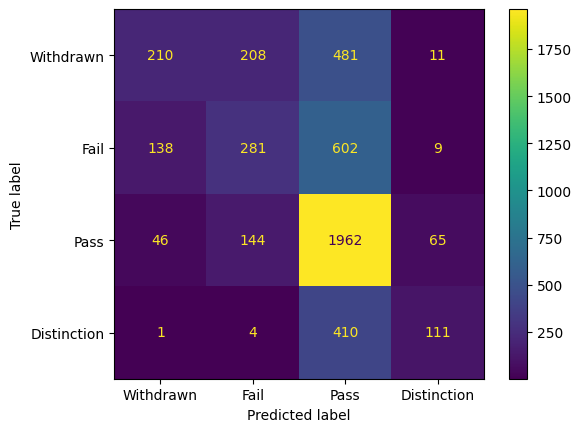

In [85]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    forest_pred,
    display_labels=[
        "Withdrawn",
        "Fail",
        "Pass",
        "Distinction"
    ]
)

#XGboost


Accuracy: 0.5513559683963272
              precision    recall  f1-score   support

   Withdrawn       0.52      0.28      0.37       910
        Fail       0.43      0.28      0.34      1030
        Pass       0.58      0.85      0.69      2217
 Distinction       0.55      0.30      0.39       526

    accuracy                           0.55      4683
   macro avg       0.52      0.43      0.44      4683
weighted avg       0.53      0.55      0.51      4683



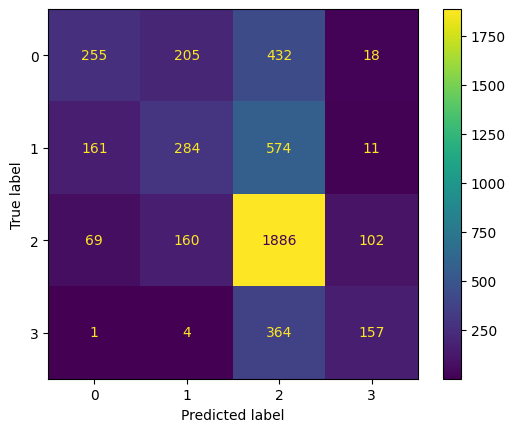

In [86]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)


base_only = [
    f for f in base_features
]

X = mlData[
    base_only +
    edu_features
]

y = mlData["target_multi"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss"
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred,
        target_names=[
            "Withdrawn",
            "Fail",
            "Pass",
            "Distinction"
        ]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

#Binary RF

In [87]:
# choose your final feature set once
feature_set = (
    base_features +
    edu_features
)

# if you want trajectory explicitly:
# feature_set = base_features + trajectory + edu_features

binary_pairs = [
    ("Pass", "Fail"),
    ("Distinction", "Fail"),
    ("Distinction", "Pass"),
    ("Withdrawn", "Pass")
]

paper_binary_results = []

for positive_class, negative_class in binary_pairs:

    pair_data = mlData[
        mlData["final_result"].isin([
            positive_class,
            negative_class
        ])
    ].copy()

    X_pair = pair_data[feature_set]

    Y_pair = (
        pair_data["final_result"]
        == positive_class
    ).astype(int)

    X_train_pair, X_test_pair, Y_train_pair, Y_test_pair = train_test_split(
        X_pair,
        Y_pair,
        test_size=0.2,
        random_state=42,
        stratify=Y_pair
    )

    model = RandomForestClassifier(
        random_state=42
    )

    model.fit(
        X_train_pair,
        Y_train_pair
    )

    pred = model.predict(X_test_pair)

    paper_binary_results.append({
        "Binary Task":
            f"{positive_class} vs {negative_class}",
        "Accuracy":
            accuracy_score(
                Y_test_pair,
                pred
            )
    })

pd.DataFrame(
    paper_binary_results
).sort_values(
    "Accuracy",
    ascending=False
)

,Binary Task,Accuracy
1,Distinction vs Fail,0.851187
2,Distinction vs Pass,0.824549
3,Withdrawn vs Pass,0.791933
0,Pass vs Fail,0.752212


In [88]:
print(mlData.shape)
print(X.shape)
print(Y.shape)
print(X_train.index[:10].tolist())
print(X_test.index[:10].tolist())

print("RF:", accuracy_score(Y_test, forest_pred))

(23411, 78)
(23411, 17)
(23411,)
[18238, 21647, 11266, 23082, 19010, 8406, 9015, 15518, 20400, 5252]
[9016, 13172, 10018, 3617, 11021, 21313, 18025, 8980, 23250, 9778]
RF: 0.5475122784539825


In [89]:
import hashlib
import json
from importlib import metadata as importlib_metadata

import numpy as np
import pandas as pd

def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()

def hash_dataframe(df: pd.DataFrame) -> str:
    payload = pd.util.hash_pandas_object(df, index=True).to_numpy().tobytes()
    return sha256_bytes(payload)

def hash_series(series: pd.Series) -> str:
    payload = pd.util.hash_pandas_object(series, index=True).to_numpy().tobytes()
    return sha256_bytes(payload)

def hash_index(index) -> str:
    payload = pd.util.hash_pandas_object(pd.Index(index), index=True).to_numpy().tobytes()
    return sha256_bytes(payload)

def print_frame(name: str, df: pd.DataFrame):
    print(f"\n=== {name} ===")
    print(f"shape: {df.shape}")
    print(f"hash: {hash_dataframe(df)}")
    print(f"index_hash: {hash_index(df.index)}")

    if name == "mlData":
        active_features = [
            "weighted_average",
            "active_days",
            "clicks_per_day",
            "clicks_per_assessment",
            "study_spread",
            "burstiness",
            "resource_ratio",
            "oucontent_ratio",
            "homepage_ratio",
            "forumng_ratio",
            "quiz_ratio",
            "assessment_focus",
            "recovery_slope",
            "highest_education_HE Qualification",
            "highest_education_Lower Than A Level",
            "highest_education_No Formal quals",
            "highest_education_Post Graduate Qualification",
        ]
        present = [col for col in active_features if col in df.columns]
        print("active_feature_value_hashes:")
        for col in present:
            print(f"  {col}: {hash_series(df[col])}")

def print_series(name: str, series: pd.Series):
    print(f"\n=== {name} ===")
    print(f"shape: {series.shape}")
    print(f"hash: {hash_series(series)}")
    print(f"index_hash: {hash_index(series.index)}")

def print_value_hash(name: str, values):
    arr = np.asarray(values)
    print(f"\n=== {name} ===")
    print(f"shape: {arr.shape}")
    print(f"hash: {sha256_bytes(arr.tobytes())}")

required = [
    "studentVleEarly",
    "studentAssessmentWithDate",
    "studentAssessmentEarly",
    "activityClicks",
    "demo",
    "registrationData",
    "mlData",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run the notebook through the preprocessing cells first.")

print_frame("studentVleEarly", studentVleEarly)
print_frame("studentAssessmentWithDate", studentAssessmentWithDate)
print_frame("studentAssessmentEarly", studentAssessmentEarly)
print_frame("activityClicks", activityClicks)

if "burst" in globals():
    print_frame("burst", burst)
elif "burstiness" in globals():
    burstiness_obj = burstiness
    if isinstance(burstiness_obj, pd.DataFrame):
        print_frame("burstiness", burstiness_obj)
    else:
        print_series("burstiness", burstiness_obj)
elif "burstiness" in activityClicks.columns:
    print_series("activityClicks['burstiness']", activityClicks["burstiness"])

if "assessment_focus" in globals():
    assessment_focus_obj = assessment_focus
    if isinstance(assessment_focus_obj, pd.DataFrame):
        print_frame("assessment_focus", assessment_focus_obj)
    else:
        print_series("assessment_focus", assessment_focus_obj)
elif "assessment_focus" in mlData.columns:
    print_series("mlData['assessment_focus']", mlData["assessment_focus"])

if "recovery_slope" in globals():
    recovery_slope_obj = recovery_slope
    if isinstance(recovery_slope_obj, pd.DataFrame):
        print_frame("recovery_slope", recovery_slope_obj)
    else:
        print_series("recovery_slope", recovery_slope_obj)
elif "recovery_slope" in mlData.columns:
    print_series("mlData['recovery_slope']", mlData["recovery_slope"])

print_frame("demo", demo)
print_frame("registrationData", registrationData)
print_frame("mlData", mlData)


=== studentVleEarly ===
shape: (4499256, 6)
hash: 75e6161443ad5c42547103e51bc36a2334171cebb82280a7d658941a3aa2eb7d
index_hash: cbb8369fd0553778a8ce4f9581180b4f8a3ecea3345580b643da31e5fdc11d09

=== studentAssessmentWithDate ===
shape: (173912, 8)
hash: cef8101bb340a10384a391997d6f37f6c80862c6ec86e7451ccadd372069d45c
index_hash: 993ff36606edc25905beef7994e3a3a646acb51d4337e0f384c1d9ffa1c0680c

=== studentAssessmentEarly ===
shape: (47259, 8)
hash: 7849b3c153625d3669b05d0cbfb5af1266448383a75f9515fde98b06a0bd0ef9
index_hash: 4c90f799afd4a0f42fca4183ee69799287a9c6def3e579af169d1750c688f22d

=== activityClicks ===
shape: (29109, 28)
hash: 64515c3172f8243ec192621fe3a4eb64140a42a4326201e2c01f4497004cd77b
index_hash: c6d890a05175f778efd4c646df07cfc3d69b320327e1377060ae6c7e716b910a

=== burst ===
shape: (29109, 6)
hash: 1c422d02d442bf9ccd998de12c68a252a40b2fa8f6d34f8d173b77f9f9ad8a41
index_hash: c6d890a05175f778efd4c646df07cfc3d69b320327e1377060ae6c7e716b910a

=== mlData['assessment_focus'] ===

In [90]:
print("CUTOFF =", CUTOFF)
print("studentVle rows:", studentVle.shape)
print("studentVle date max:", studentVle["date"].max())

for c in [14, 30, 60, 90, 140]:
    print(c, (studentVle["date"] <= c).sum())

print("studentVleEarly shape:", studentVleEarly.shape)

CUTOFF = 60
studentVle rows: (10655280, 6)
studentVle date max: 269
14 1819777
30 2980575
60 4499256
90 5486878
140 7356543
studentVleEarly shape: (4499256, 6)


In [91]:
import os

print(os.path.getsize("studentVle.csv"))

453836331


In [92]:
import hashlib

with open("studentVle.csv", "rb") as f:
    print(hashlib.md5(f.read()).hexdigest())

b8aae6f4ffd1523319aeb56d66b17f72


In [93]:
import hashlib

def df_hash(df):
    return hashlib.sha256(
        pd.util.hash_pandas_object(df, index=True).values.tobytes()
    ).hexdigest()

print(df_hash(studentVleEarly))

75e6161443ad5c42547103e51bc36a2334171cebb82280a7d658941a3aa2eb7d


In [94]:
print("mlData:", mlData.shape)
print("X:", X.shape)
print("Y or y:", Y.shape if "Y" in globals() else y.shape)

print("features:")
print(list(X.columns))

print("target counts:")
print(mlData["target_multi"].value_counts().sort_index())

mlData: (23411, 78)
X: (23411, 17)
Y or y: (23411,)
features:
['weighted_average', 'active_days', 'clicks_per_day', 'clicks_per_assessment', 'study_spread', 'burstiness', 'resource_ratio', 'oucontent_ratio', 'homepage_ratio', 'forumng_ratio', 'quiz_ratio', 'assessment_focus', 'recovery_slope', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification']
target counts:
target_multi
0     4400
1     5163
2    11220
3     2628
Name: count, dtype: int64


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = mlData[base_features + edu_features]
Y = mlData["target_multi"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300
)

rf.fit(X_train, Y_train)
forest_pred = rf.predict(X_test)

print("RF accuracy:", accuracy_score(Y_test, forest_pred))
print(classification_report(
    Y_test,
    forest_pred,
    target_names=["Withdrawn", "Fail", "Pass", "Distinction"]
))

RF accuracy: 0.5475122784539825
              precision    recall  f1-score   support

   Withdrawn       0.53      0.23      0.32       910
        Fail       0.44      0.27      0.34      1030
        Pass       0.57      0.88      0.69      2217
 Distinction       0.57      0.21      0.31       526

    accuracy                           0.55      4683
   macro avg       0.53      0.40      0.41      4683
weighted avg       0.53      0.55      0.50      4683



In [96]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = mlData[base_features + edu_features]
y = mlData["target_multi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

print("XGB accuracy:", accuracy_score(y_test, pred))
print(classification_report(
    y_test,
    pred,
    target_names=["Withdrawn", "Fail", "Pass", "Distinction"]
))

XGB accuracy: 0.5513559683963272
              precision    recall  f1-score   support

   Withdrawn       0.52      0.28      0.37       910
        Fail       0.43      0.28      0.34      1030
        Pass       0.58      0.85      0.69      2217
 Distinction       0.55      0.30      0.39       526

    accuracy                           0.55      4683
   macro avg       0.52      0.43      0.44      4683
weighted avg       0.53      0.55      0.51      4683



In [97]:
import hashlib

print(
    hashlib.sha256(
        pd.util.hash_pandas_object(
            mlData,
            index=True
        ).values.tobytes()
    ).hexdigest()
)

a78e21dac590d7fe37938951a2f2b55e4eb5193f91db1d098bfcab184b2cbc46


In [98]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(18728, 17)
(4683, 17)
target_multi
2    9003
1    4133
0    3490
3    2102
Name: count, dtype: int64
target_multi
2    2217
1    1030
0     910
3     526
Name: count, dtype: int64


In [99]:
print(mlData.isna().sum().sum())

0


In [100]:
print(
    mlData["id_student"].duplicated().sum()
)

2376


In [101]:
print(sorted(base_features))
print(sorted(edu_features))

['active_days', 'assessment_focus', 'burstiness', 'clicks_per_assessment', 'clicks_per_day', 'forumng_ratio', 'homepage_ratio', 'oucontent_ratio', 'quiz_ratio', 'recovery_slope', 'resource_ratio', 'study_spread', 'weighted_average']
['highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification']


In [102]:
print(mlData[["id_student", "code_module", "code_presentation"]].duplicated().sum())

0


In [103]:
print(
    mlData.groupby("id_student")
          .size()
          .sort_values(ascending=False)
          .head(20)
)

id_student
2681198    4
610287     4
584077     4
587122     4
80329      4
596620     4
616407     4
585769     4
473095     3
471580     3
490297     3
171896     3
632074     3
565883     3
554459     3
479607     3
630200     3
592259     3
599297     3
628366     3
dtype: int64


In [104]:
print(
    mlData[
        mlData["id_student"].duplicated(keep=False)
    ][
        ["id_student",
         "code_module",
         "code_presentation"]
    ].head(30)
)

     id_student code_module code_presentation
1          8462         DDD             2013J
2          8462         DDD             2014J
21        27417         DDD             2013J
22        27417         DDD             2014J
26        27891         BBB             2013B
27        27891         BBB             2014B
39        29411         CCC             2014J
40        29411         DDD             2013J
42        29639         CCC             2014J
43        29639         EEE             2014B
46        29820         CCC             2014B
47        29820         EEE             2014B
69        33681         DDD             2013J
70        33681         DDD             2014J
72        33897         DDD             2013J
73        33897         DDD             2014J
77        34087         DDD             2013J
78        34087         DDD             2014J
89        35355         CCC             2014J
90        35355         EEE             2013J
92        35508         CCC       

In [105]:
print(mlData.columns.tolist())

['id_student', 'code_module', 'code_presentation', 'weighted_score', 'weight', 'weighted_average', 'final_result', 'active_days', 'sum_click', 'clicks_per_day', 'success', 'target_multi', 'assessment_count', 'coursework_count', 'score_std', 'clicks_per_assessment', 'total_assessments', 'completion_ratio', 'click_consistency', 'study_spread', 'score_slope', 'burstiness', 'resource_ratio', 'oucontent_ratio', 'homepage_ratio', 'forumng_ratio', 'quiz_ratio', 'num_of_prev_attempts', 'studied_credits', 'gender_M', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'age_band_35-55', 'age_band_55<=', 'disability_Y', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'imd_band_?', 'disappearance_ratio', 'registration_lead', 'deadline_panic_score', 'assessment_focus'

# Binary evaluation — Baseline v4 protocol

The four pairwise tasks from the original `#Binary RF` section, re-run under the
**official v4 protocol**: v4 population (`mlDataV4`), grouped split
(`GroupShuffleSplit`, group=`id_student`, test_size=0.2, seed 42 — no student in
both train and test), and the verified feature sets. The model is unchanged from
the original binary cell (`RandomForestClassifier(random_state=42)`); the original
cell above is preserved as history (it used the pre-v2 features, the old
population, and a random row split).

Both the official v3 (19) and v4 (35) feature sets are evaluated on **identical
splits**, so the delta isolates the effect of the 16 promoted features. Results:
`reports/binary_v4.md`. Requires the Baseline v4 cell above to have run
(`mlDataV4`, `v3_features`, `v4_features`).

In [ ]:
# =====================================================================
# Binary evaluation — Baseline v4 protocol (additive section)
# =====================================================================
# The four pairwise tasks from the original "#Binary RF" section, re-run
# under the official protocol: v4 population (mlDataV4), grouped split
# (GroupShuffleSplit, group=id_student, test_size=0.2, random_state=42),
# verified feature sets. Model unchanged from the original binary cell:
# RandomForestClassifier(random_state=42). Both the official v3 (19) and
# v4 (35) feature sets are evaluated on identical splits so the effect of
# the promoted features is isolated. Nothing above this cell is modified.
# =====================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score)

_bin_pairs = [
    ("Pass", "Fail"),
    ("Distinction", "Fail"),
    ("Distinction", "Pass"),
    ("Withdrawn", "Pass"),
]
_bin_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

binary_v4_results = {
    "cutoff": CUTOFF,
    "population": "mlDataV4 (v3 risk population + verified v4 features)",
    "split": {"strategy": "GroupShuffleSplit(group=id_student)",
              "test_size": 0.2, "random_state": 42},
    "model": "RandomForestClassifier(random_state=42)",
    "feature_sets": {"v3": len(v3_features), "v4": len(v4_features)},
    "tasks": {},
}

for _pos, _neg in _bin_pairs:
    _bd = mlDataV4[mlDataV4["final_result"].isin([_pos, _neg])].copy()
    _yb = (_bd["final_result"] == _pos).astype(int)
    _gb = _bd["id_student"].values
    _trb, _teb = next(_bin_gss.split(_bd, _yb, groups=_gb))
    assert len(set(_gb[_trb]) & set(_gb[_teb])) == 0   # no student overlap
    _task = {
        "n_train": int(len(_trb)), "n_test": int(len(_teb)),
        "pos_rate_test": float(_yb.iloc[_teb].mean()),
    }
    for _fsname, _fs in (("v3", v3_features), ("v4", v4_features)):
        _Xb = _bd[_fs]
        _mb = RandomForestClassifier(random_state=42)
        _mb.fit(_Xb.iloc[_trb], _yb.iloc[_trb])
        _pb = _mb.predict(_Xb.iloc[_teb])
        _task[_fsname] = {
            "accuracy": float(accuracy_score(_yb.iloc[_teb], _pb)),
            "f1_pos": float(f1_score(_yb.iloc[_teb], _pb, zero_division=0)),
            "precision_pos": float(precision_score(_yb.iloc[_teb], _pb,
                                                   zero_division=0)),
            "recall_pos": float(recall_score(_yb.iloc[_teb], _pb,
                                             zero_division=0)),
        }
    binary_v4_results["tasks"][f"{_pos} vs {_neg}"] = _task
    print(f"[binary v4] c{CUTOFF:>3} {_pos} vs {_neg}: "
          f"acc v3={_task['v3']['accuracy']:.4f} -> v4={_task['v4']['accuracy']:.4f} "
          f"(d={_task['v4']['accuracy'] - _task['v3']['accuracy']:+.4f}) | "
          f"F1+ v4={_task['v4']['f1_pos']:.4f}")

print("[binary v4] CUTOFF =", CUTOFF, "| tasks:", len(binary_v4_results["tasks"]))